# Linear OT Coordinates

This notebook generates `fig:dualnorms-linear-ot-embedding`.  Linear OT fixes a reference law $\rho$ and represents a target $\mu$ by its Brenier map $T_\mu$ from $\rho$ to $\mu$.
In one dimension, $T_\mu=Q_\mu\circ F_\rho$ and the Wasserstein barycenter is obtained by averaging quantile maps:
$$
    T_\gamma = \frac{T_\alpha+T_\beta}{2},
    \qquad \gamma=(T_\gamma)_\#\rho .
$$
The first row therefore plots the maps themselves, not $T_\mu-\mathrm{Id}$.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")

sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
import numpy as np

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    ORANGE,
    GRAY,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    box_axes,
    draw_point_clouds,
    draw_transport_segments,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

import ot
from scipy.ndimage import gaussian_filter1d
from scipy.stats import gaussian_kde

NAME = "dualnorms-linear-ot-embedding"
OUT = figure_dir(NAME)
rng = np.random.default_rng(811)

## One-dimensional quantile maps

The one-dimensional target $\alpha$ is a narrow two-Gaussian mixture, while $\beta$ is now a right-shifted mixture of two Gaussians.  In one dimension, linear OT around a reference density is exact: the map coordinates are quantile functions.  Averaging the maps $T_\alpha$ and $T_\beta$ therefore gives the Wasserstein barycenter map $T_\gamma=(T_\alpha+T_\beta)/2$.  The quantile grid is deliberately dense so that the reconstructed density interpolation is smooth.


In [2]:
def gaussian(x, m, s):
    return np.exp(-0.5 * ((x - m) / s) ** 2) / (np.sqrt(2 * np.pi) * s)


def normalize_density(x, rho):
    dx = x[1] - x[0]
    return rho / (rho.sum() * dx)


def quantile_from_density(x, rho, r):
    dx = x[1] - x[0]
    F = np.cumsum(rho) * dx
    F = np.maximum.accumulate(F)
    F[-1] = 1.0
    return np.interp(r, F, x)

x = np.linspace(-4.0, 4.0, 3200)
r = np.linspace(1e-5, 1 - 1e-5, 2200)
rho_ref = normalize_density(x, gaussian(x, 0.0, 0.72))
rho_a = normalize_density(
    x,
    0.46 * gaussian(x, -1.48, 0.16)
    + 0.54 * gaussian(x, -0.74, 0.18),
)
rho_b = normalize_density(
    x,
    0.42 * gaussian(x, 0.72, 0.17)
    + 0.58 * gaussian(x, 1.72, 0.20),
)
Qref = quantile_from_density(x, rho_ref, r)
Ta = quantile_from_density(x, rho_a, r)
Tb = quantile_from_density(x, rho_b, r)
Tg = 0.5 * (Ta + Tb)

def density_from_quantile(q, r, grid):
    deriv = np.maximum(np.gradient(q, r), 1e-5)
    dens_at_q = 1.0 / deriv
    order = np.argsort(q)
    vals = np.interp(grid, q[order], dens_at_q[order], left=0.0, right=0.0)
    return gaussian_filter1d(vals, sigma=0.95)

rho_g = normalize_density(x, density_from_quantile(Tg, r, x))

In [3]:
fig, ax = plt.subplots(figsize=(2.95, 1.86))
ax.plot(Qref, Ta, color=RED, lw=1.10, label=r"$T_\alpha$")
ax.plot(Qref, Tb, color=BLUE, lw=1.10, label=r"$T_\beta$")
ax.plot(Qref, Tg, color=VIOLET, lw=1.38, label=r"$T_\gamma$")
ax.plot(Qref, Qref, color=LIGHT_GRAY, lw=0.72, alpha=0.95)
ax.set_xlim(-2.65, 2.65)
ax.set_ylim(-2.28, 2.42)
ax.tick_params(labelbottom=False, labelleft=False)
leg = ax.legend(frameon=False, loc="upper left", handlelength=1.2, borderaxespad=0.15, fontsize=7.8)
for text, color in zip(leg.get_texts(), [RED, BLUE, VIOLET]):
    text.set_color(color)
box_axes(ax)
save_pdf(fig, OUT / "displacements-1d.pdf", pad_inches=0.045)
plt.close(fig)

fig, ax = plt.subplots(figsize=(2.95, 1.86))
ax.plot(x, rho_a, color=RED, lw=1.10, label=r"$\alpha$")
ax.plot(x, rho_b, color=BLUE, lw=1.10, label=r"$\beta$")
ax.plot(x, rho_g, color=VIOLET, lw=1.38, label=r"$\gamma$")
ax.set_xlim(-2.25, 2.55)
ax.set_ylim(0, 1.95)
ax.tick_params(labelbottom=False, labelleft=False)
leg = ax.legend(frameon=False, loc="upper right", handlelength=1.2, borderaxespad=0.15, fontsize=7.8)
for text, color in zip(leg.get_texts(), [RED, BLUE, VIOLET]):
    text.set_color(color)
box_axes(ax)
save_pdf(fig, OUT / "barycenter-1d.pdf", pad_inches=0.045)
plt.close(fig)

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


## Two-dimensional map averaging

For the two-dimensional panels, a dense central disk reference $\rho$ is displayed in black and mapped to two farther target mixtures.  The blue target $\beta$ is a two-Gaussian mixture, while $\alpha$ keeps three components to make the linearized barycenter nontrivial.  We compute the transport maps on a denser sample than the displayed subset, and use all computed particles for the KDE contours.


In [4]:
def farthest_point_sample(points, n):
    pts = np.asarray(points)
    idx = np.empty(n, dtype=int)
    idx[0] = int(np.argmin(np.sum((pts - pts.mean(axis=0)) ** 2, axis=1)))
    dist2 = np.sum((pts - pts[idx[0]]) ** 2, axis=1)
    for k in range(1, n):
        idx[k] = int(np.argmax(dist2))
        dist2 = np.minimum(dist2, np.sum((pts - pts[idx[k]]) ** 2, axis=1))
    return idx


def uniform_disk(n, radius=0.54):
    theta = rng.uniform(0, 2*np.pi, n)
    rad = radius * np.sqrt(rng.uniform(0, 1, n))
    return np.column_stack([rad*np.cos(theta), rad*np.sin(theta)])


def sample_mixture(weights, centers, covs, n):
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()
    counts = rng.multinomial(n, weights)
    parts = [rng.multivariate_normal(c, S, size=k) for c, S, k in zip(centers, covs, counts)]
    pts = np.vstack(parts)
    rng.shuffle(pts)
    return pts


n = 940
reference = uniform_disk(n)

alpha_spec = dict(
    weights=np.array([0.44, 0.36, 0.20]),
    centers=np.array([[-1.58, 0.68], [-1.46, -0.66], [-0.78, 0.02]]),
    covs=np.array([[[0.032, 0.008], [0.008, 0.058]], [[0.052, -0.014], [-0.014, 0.032]], [[0.026, 0.0], [0.0, 0.026]]]),
)
beta_spec = dict(
    weights=np.array([0.47, 0.53]),
    centers=np.array([[1.45, 0.60], [1.58, -0.56]]),
    covs=np.array([[[0.046, -0.012], [-0.012, 0.034]], [[0.036, 0.014], [0.014, 0.060]]]),
)

alpha_target = sample_mixture(n=n, **alpha_spec)
beta_target = sample_mixture(n=n, **beta_spec)

a = b = np.full(n, 1.0 / n)
P_a = ot.emd(a, b, ot.dist(reference, alpha_target, metric="sqeuclidean"), numItermax=900000)
P_b = ot.emd(a, b, ot.dist(reference, beta_target, metric="sqeuclidean"), numItermax=900000)
T_a = n * P_a @ alpha_target
T_b = n * P_b @ beta_target
T_g = 0.5 * (T_a + T_b)
P_ab = ot.emd(a, b, ot.dist(alpha_target, beta_target, metric="sqeuclidean"), numItermax=900000)
T_ab = n * P_ab @ beta_target
T_mccann = 0.5 * (alpha_target + T_ab)

idx_ref = farthest_point_sample(reference, 110)
idx_arrows = idx_ref[::2]
idx_alpha = farthest_point_sample(alpha_target, 165)
idx_beta = farthest_point_sample(beta_target, 165)
idx_gamma = farthest_point_sample(T_g, 210)
idx_mccann = farthest_point_sample(T_mccann, 210)
all_points_2d = np.vstack([reference, alpha_target, beta_target, T_g, T_mccann])
xlim_2d, ylim_2d = padded_limits(all_points_2d, pad=0.07)


In [5]:
def finish_cloud_axis(ax):
    ax.set_xlim(*xlim_2d)
    ax.set_ylim(*ylim_2d)
    ax.set_aspect("equal")
    remove_axes(ax)


def draw_kde_contours(ax, points, color, *, alpha=0.70, fill=False, bw=0.22, zorder=2):
    gx = np.linspace(xlim_2d[0], xlim_2d[1], 156)
    gy = np.linspace(ylim_2d[0], ylim_2d[1], 132)
    X, Y = np.meshgrid(gx, gy)
    kde = gaussian_kde(points.T, bw_method=bw)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    levels = np.linspace(Z.max() * 0.14, Z.max() * 0.86, 7)
    if fill:
        ax.contourf(X, Y, Z, levels=levels, colors=[color], alpha=0.08, zorder=zorder - 1)
    ax.contour(X, Y, Z, levels=levels, colors=[color], linewidths=0.54, alpha=alpha, zorder=zorder)


def draw_arrows(ax, src, dst, color, *, alpha=0.44):
    delta = dst - src
    ax.quiver(
        src[:, 0],
        src[:, 1],
        delta[:, 0],
        delta[:, 1],
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.0020,
        headwidth=4.0,
        headlength=5.0,
        headaxislength=4.2,
        color=color,
        alpha=alpha,
        zorder=2,
    )


fig, ax = plt.subplots(figsize=(2.72, 2.05))
draw_kde_contours(ax, reference, "#111111", alpha=0.36, bw=0.30, zorder=1)
draw_kde_contours(ax, alpha_target, RED, alpha=0.58, bw=0.23, zorder=3)
draw_kde_contours(ax, beta_target, BLUE, alpha=0.58, bw=0.23, zorder=3)
draw_arrows(ax, reference[idx_arrows], T_a[idx_arrows], RED)
draw_arrows(ax, reference[idx_arrows], T_b[idx_arrows], BLUE)
ax.scatter(reference[idx_ref, 0], reference[idx_ref, 1], s=DIRAC_MARKER_SIZE * 0.34, marker="o", color="#111111", edgecolor="none", linewidth=0, alpha=0.72, zorder=4)
ax.scatter(alpha_target[idx_alpha, 0], alpha_target[idx_alpha, 1], s=DIRAC_MARKER_SIZE * 0.30, marker="o", color=RED, edgecolor="none", linewidth=0, alpha=0.55, zorder=5)
ax.scatter(beta_target[idx_beta, 0], beta_target[idx_beta, 1], s=DIRAC_MARKER_SIZE * 0.30, marker="o", color=BLUE, edgecolor="none", linewidth=0, alpha=0.55, zorder=5)
finish_cloud_axis(ax)
save_pdf(fig, OUT / "targets-2d.pdf", pad_inches=0.035)
plt.close(fig)

fig, ax = plt.subplots(figsize=(2.72, 2.05))
draw_kde_contours(ax, T_g, VIOLET, alpha=0.82, fill=True, bw=0.22, zorder=3)
ax.scatter(T_g[idx_gamma, 0], T_g[idx_gamma, 1], s=DIRAC_MARKER_SIZE * 0.36, marker="o", color=VIOLET, edgecolor="none", linewidth=0, alpha=0.68, zorder=4)
finish_cloud_axis(ax)
save_pdf(fig, OUT / "barycenter-2d.pdf", pad_inches=0.035)
plt.close(fig)

fig, ax = plt.subplots(figsize=(2.72, 2.05))
draw_kde_contours(ax, T_mccann, VIOLET, alpha=0.82, fill=True, bw=0.22, zorder=3)
ax.scatter(T_mccann[idx_mccann, 0], T_mccann[idx_mccann, 1], s=DIRAC_MARKER_SIZE * 0.36, marker="o", color=VIOLET, edgecolor="none", linewidth=0, alpha=0.68, zorder=4)
finish_cloud_axis(ax)
save_pdf(fig, OUT / "barycenter-2d-ot.pdf", pad_inches=0.035)
plt.close(fig)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


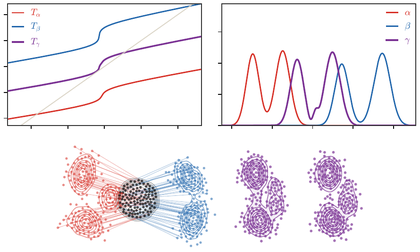

In [6]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/dualnorms-linear-ot-embedding.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/dualnorms-linear-ot-embedding.png")
display(Image(filename=str(_thumb)))
